In [1]:
import zipfile
import os
def unzip_dataset(zip_file_path, extraction_path):
    if not os.path.exists(extraction_path):
        os.makedirs(extraction_path)

    # Open the zip file
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extraction_path)

    print(f"Dataset successfully extracted to {extraction_path}")

# Example usage
zip_file_path = 'C:/Users/amaiy/Desktop/NewVSCodeEnvironmentForPython/plant_village.zip'
extraction_path = 'PlantVillageData'

unzip_dataset(zip_file_path, extraction_path)

Dataset successfully extracted to PlantVillageData


In [2]:
from keras import applications
from keras import optimizers
from keras.models import Sequential, Model
from keras.layers import Dropout, Flatten, Dense, GlobalAveragePooling2D
from keras import backend as k 
from keras.callbacks import ModelCheckpoint, LearningRateScheduler, TensorBoard, EarlyStopping

In [3]:
import numpy as np
import keras
from keras import models
import matplotlib.pyplot as plt
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential, Model
from keras.optimizers import SGD
from keras import layers
from keras.layers import Dense , Flatten, Conv2D, MaxPooling2D
from keras import Input

In [4]:
#Normalize training and validation data in range 0 to 1
train_datagen=ImageDataGenerator(rescale=1./255)
validation_datagen=ImageDataGenerator(rescale=1./255)
test_datagen=ImageDataGenerator(rescale=1./255)

In [5]:
train_generator = train_datagen.flow_from_directory(
    'C:/Users/amaiy/Desktop/NewVSCodeEnvironmentForPython/PlantVillageData/plant_village/train',
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = validation_datagen.flow_from_directory(
    'C:/Users/amaiy/Desktop/NewVSCodeEnvironmentForPython/PlantVillageData/plant_village/val',
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    'C:/Users/amaiy/Desktop/NewVSCodeEnvironmentForPython/PlantVillageData/plant_village/test',
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 3002 images belonging to 4 classes.
Found 635 images belonging to 4 classes.
Found 546 images belonging to 4 classes.


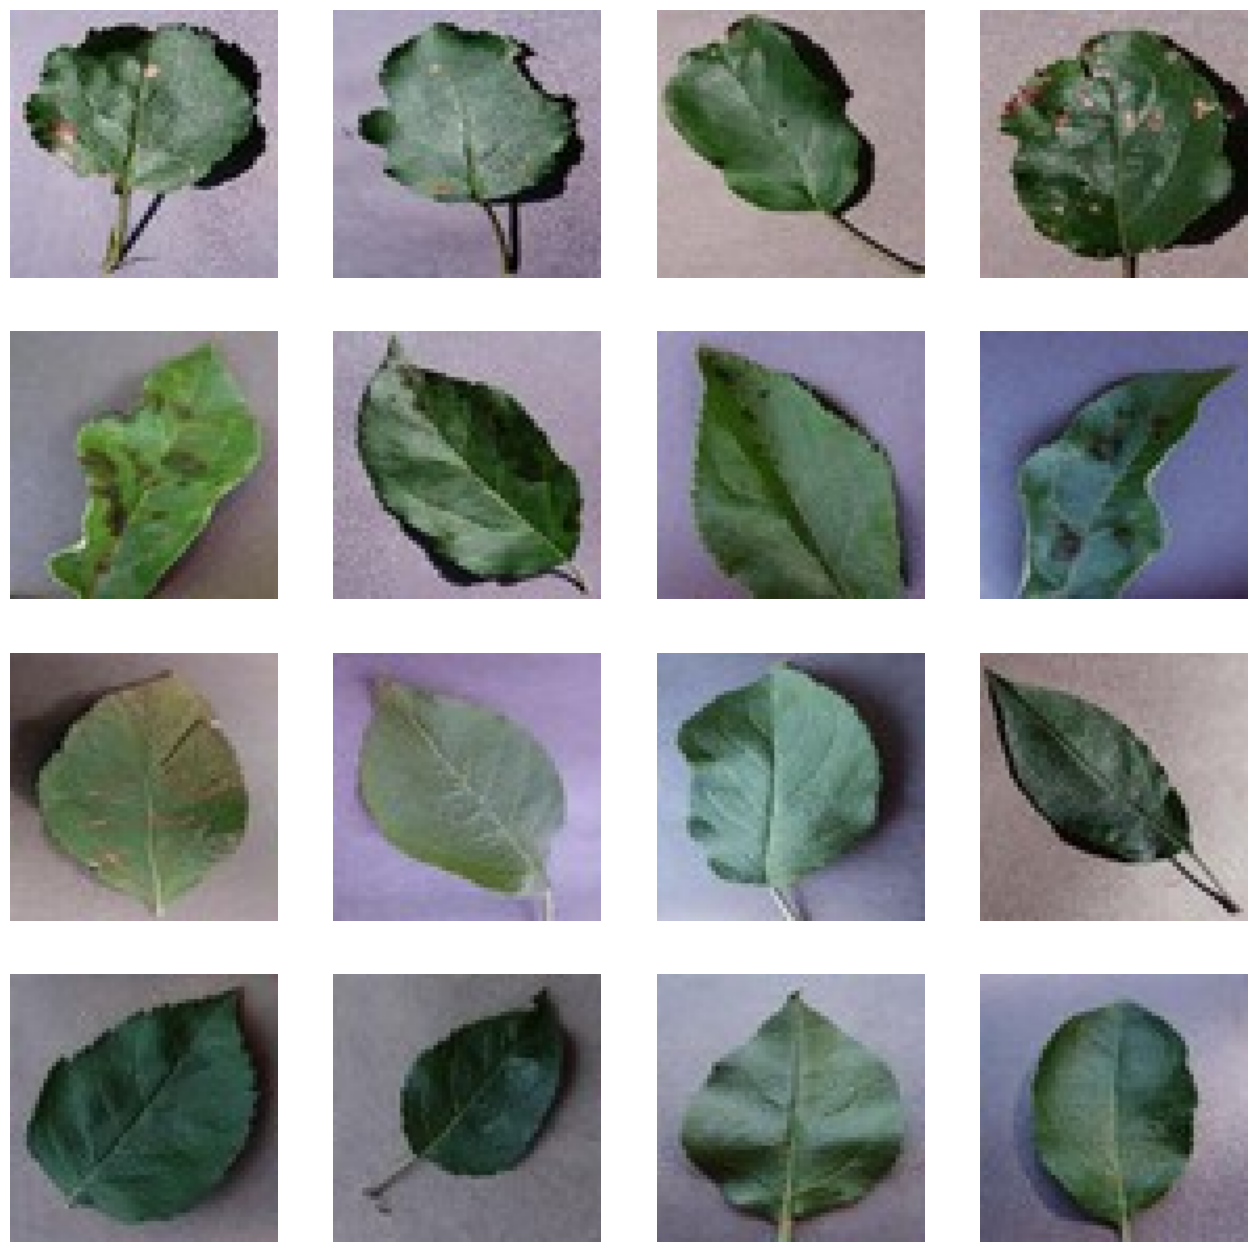

In [6]:
plt.figure(figsize=(16, 16))
for i in range(1, 17):
    plt.subplot(4, 4, i)
    images, labels = next(test_generator)
    plt.imshow(images[0])
    plt.axis('off')
plt.show()

In [7]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(128,128,3))

base_model.trainable=False
base_model.summary()

A local file was found, but it seems to be incomplete or outdated because the auto file hash does not match the original value of 4d473c1dd8becc155b73f8504c6f6626 so we will re-download the data.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [8]:
flatten_layer=layers.GlobalAveragePooling2D()
prediction_layer=Dense(4, activation='softmax')
model=models.Sequential([
    base_model,
    flatten_layer,
    prediction_layer])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,595,908 (90.01 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [9]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
num_classes = train_generator.num_classes

output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)


In [10]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


In [11]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


In [12]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

In [13]:
val_datagen = ImageDataGenerator(rescale=1./255)

In [14]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',   # or sparse_categorical_crossentropy
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stopping]
)


Epoch 1/20


c:\Users\amaiy\Desktop\NewVSCodeEnvironmentForPython\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


94/94 ━━━━━━━━━━━━━━━━━━━━ 42s 374ms/step - accuracy: 0.4624 - loss: 1.2549 - val_accuracy: 0.5276 - val_loss: 1.1963
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 31s 335ms/step - accuracy: 0.4704 - loss: 1.1886 - val_accuracy: 0.5197 - val_loss: 1.0984
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 48s 507ms/step - accuracy: 0.5027 - loss: 1.1441 - val_accuracy: 0.5622 - val_loss: 1.0502
Epoch 4/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 51s 538ms/step - accuracy: 0.5237 - loss: 1.0882 - val_accuracy: 0.5811 - val_loss: 1.0044
Epoch 5/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 50s 532ms/step - accuracy: 0.5593 - loss: 1.0417 - val_accuracy: 0.5858 - val_loss: 0.9699
Epoch 6/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 49s 520ms/step - accuracy: 0.5713 - loss: 1.0052 - val_accuracy: 0.6000 - val_loss: 0.9344
Epoch 7/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 39s 411ms/step - accuracy: 0.5706 - loss: 0.9738 - val_accuracy: 0.6142 - val_loss: 0.9118
Epoch 8/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 50s 528ms/step - accuracy: 0.5893 - loss: 0.9464 - val_accuracy: 0.600

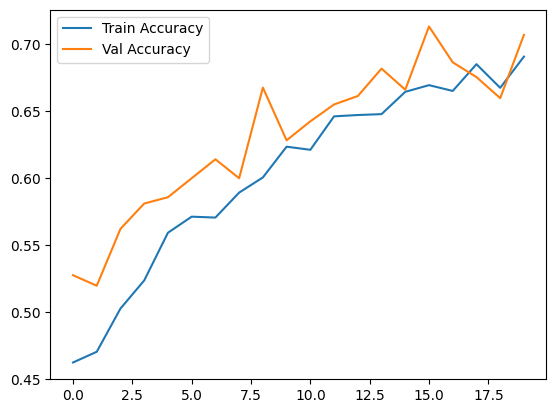

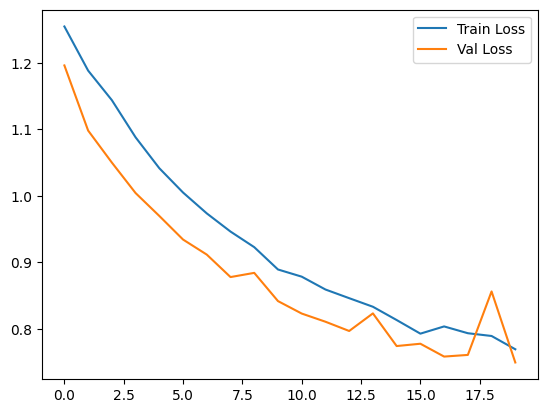

In [16]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()


In [17]:
loss, acc = model.evaluate(validation_generator)
print("Validation Accuracy:", acc)


20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 243ms/step - accuracy: 0.7071 - loss: 0.7496
Validation Accuracy: 0.7070866227149963


In [18]:
import numpy as np

validation_generator.reset()

y_pred_probs = model.predict(validation_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = validation_generator.classes

class_labels = list(validation_generator.class_indices.keys())


20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 297ms/step


In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

print(cm)

[[101   8   0  15]
 [  5  49   6  67]
 [  0   6   8  41]
 [ 26  10   2 291]]


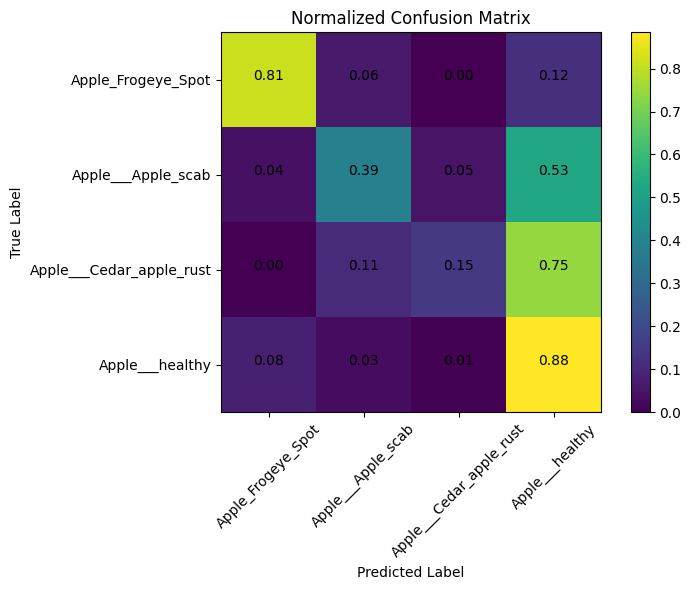

In [20]:
import matplotlib.pyplot as plt
import itertools
import numpy as np

plt.figure(figsize=(8,6))
plt.imshow(cm_normalized, interpolation='nearest')
plt.title("Normalized Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_labels))
plt.xticks(tick_marks, class_labels, rotation=45)
plt.yticks(tick_marks, class_labels)

for i, j in itertools.product(range(cm_normalized.shape[0]), range(cm_normalized.shape[1])):
    plt.text(j, i, f"{cm_normalized[i, j]:.2f}", horizontalalignment="center")

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()
